# Imports

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.metrics import precision_recall_curve

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50, ResNet50_Weights
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
sns.set(style="whitegrid", font_scale=1.1)


Using device: cuda


# Data path

In [ ]:
DATASET_ROOT = "/kaggle/input/npz-to-jpg"
PREPROC_DIR   = os.path.join(DATASET_ROOT, "preprocessed_data")

OLD_PREFIX = "/kaggle/working/preprocessed_data"
NEW_PREFIX = PREPROC_DIR

IMAGES_DIR = os.path.join(PREPROC_DIR, "images")
META_DIR   = os.path.join(PREPROC_DIR, "metadata")

train_meta_path = os.path.join(META_DIR, "train_metadata.csv")
val_meta_path   = os.path.join(META_DIR, "val_metadata.csv")
test_meta_path  = os.path.join(META_DIR, "test_metadata.csv")

label_map_path  = os.path.join(META_DIR, "label_mapping.json")

print(train_meta_path)
print(val_meta_path)
print(test_meta_path)
print(label_map_path)

# Load label mapping
with open(label_map_path, "r") as f:
    label_map = json.load(f)

label_to_class = label_map["label_to_class"]
class_to_label = label_map["class_to_label"]

# Convert keys to int where needed
label_to_class = {int(k): v for k, v in label_to_class.items()}

class_names = [label_to_class[0], label_to_class[1]]
num_classes = 2

print("label_to_class:", label_to_class)
print("class_to_label:", class_to_label)
print("class_names:", class_names)

# Load metadata CSVs
train_df = pd.read_csv(train_meta_path)
val_df   = pd.read_csv(val_meta_path)
test_df  = pd.read_csv(test_meta_path)

for df in [train_df, val_df, test_df]:
    df["image_path"] = df["image_path"].str.replace(
        OLD_PREFIX, NEW_PREFIX, regex=False
    )

print(train_df.head())


/kaggle/input/npz-to-jpg/preprocessed_data/metadata/train_metadata.csv
/kaggle/input/npz-to-jpg/preprocessed_data/metadata/val_metadata.csv
/kaggle/input/npz-to-jpg/preprocessed_data/metadata/test_metadata.csv
/kaggle/input/npz-to-jpg/preprocessed_data/metadata/label_mapping.json
label_to_class: {0: 'Non_Fractured', 1: 'Fractured'}
class_to_label: {'Non_Fractured': 0, 'Fractured': 1}
class_names: ['Non_Fractured', 'Fractured']
              image_id                                         image_path  \
0       IMG0001474.jpg  /kaggle/input/npz-to-jpg/preprocessed_data/ima...   
1  IMG0001474_aug1.jpg  /kaggle/input/npz-to-jpg/preprocessed_data/ima...   
2       IMG0003256.jpg  /kaggle/input/npz-to-jpg/preprocessed_data/ima...   
3  IMG0003256_aug1.jpg  /kaggle/input/npz-to-jpg/preprocessed_data/ima...   
4       IMG0004045.jpg  /kaggle/input/npz-to-jpg/preprocessed_data/ima...   

   label     label_name  split  augmented          shape    dtype  
0      0  Non_Fractured  train      Fa

# .npz image data loading

In [ ]:
from PIL import Image

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_npz_image(path):

    data = np.load(path)
    if "image" in data:
        img = data["image"]
    else:

        key = list(data.keys())[0]
        img = data[key]

    img = np.array(img)

    # Handle grayscale or channel-first cases
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    elif img.ndim == 3:
        if img.shape[0] in [1, 3] and img.shape[0] < img.shape[-1]:
            img = np.transpose(img, (1, 2, 0))
        if img.shape[-1] == 1:
            img = np.repeat(img, 3, axis=-1)

    # scale to [0,255]
    if img.dtype != np.uint8:
        img_min, img_max = img.min(), img.max()
        if img_max > 1.0 or img_min < 0.0:
            img = (img - img_min) / (img_max - img_min + 1e-8)
        img = (img * 255.0).astype(np.uint8)

    return img

class NPZFractureDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _fix_path(self, raw_path: str) -> str:

        if raw_path.startswith(OLD_PREFIX):
            return raw_path.replace(OLD_PREFIX, NEW_PREFIX)
        else:

            fname = os.path.basename(raw_path)

            return os.path.join(NEW_PREFIX, "images", self.split, fname)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        raw_path = row["image_path"]
        self.split = row.get("split", "train")

        img_path = self._fix_path(raw_path)
        img_np   = load_npz_image(img_path)
        img_pil  = Image.fromarray(img_np)

        label = int(row["label"])

        if self.transform:
            img = self.transform(img_pil)
        else:
            img = transforms.ToTensor()(img_pil)

        return img, label


# Data Loader and batch size confg

In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 16
NUM_WORKERS = 2
SEED = 42

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = NPZFractureDataset(train_df, transform=train_transform)
val_dataset   = NPZFractureDataset(val_df,   transform=eval_transform)
test_dataset  = NPZFractureDataset(test_df,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

# Class weights from train metadata
class_counts = train_df["label"].value_counts().sort_index().values
print("Train class counts:", dict(zip(class_names, class_counts)))

total = class_counts.sum()
class_weights = [total / (num_classes * c) for c in class_counts]
print("Class weights:", class_weights)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)


Train batches: 546
Val batches: 39
Test batches: 39
Train class counts: {'Non_Fractured': 4712, 'Fractured': 4016}
Class weights: [0.9261460101867572, 1.0866533864541832]


# Network architecture {EfficientnetB0, Resnet50}

In [ ]:
def build_efficientnet_b0(num_classes=2, freeze=True):
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    if freeze:
        for p in model.features.parameters():
            p.requires_grad = False
    return model

def build_resnet50(num_classes=2, freeze=True):
    weights = ResNet50_Weights.IMAGENET1K_V2
    model = resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    if freeze:
        for name, p in model.named_parameters():
            if "fc" not in name:
                p.requires_grad = False
    return model


## Severity-Aware Loss Function (Clinical Novelty)


In [ ]:
import torch
import torch.nn as nn

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SeverityAwareLoss(nn.Module):
    def __init__(self, severity_matrix):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(reduction='none')
        self.severity = severity_matrix

    def forward(self, outputs, targets):
        ce_loss = self.ce(outputs, targets)
        preds = torch.argmax(outputs, dim=1)
        penalties = self.severity[targets, preds]
        return (ce_loss * penalties).mean()


# Binary class mapping used in the project:
# 0 -> Class 0 (Negative / Non-target)
# 1 -> Class 1 (Positive / Target)
#
# False Negative (1 -> 0) is penalized more than False Positive (0 -> 1)
severity_matrix = torch.tensor([
    [1.0, 1.5],  # True class 0 → FP has moderate penalty
    [2.0, 1.0]   # True class 1 → FN has high penalty
], dtype=torch.float32).to(device)

criterion = SeverityAwareLoss(severity_matrix)

print("Severity-Aware Loss (Binary) enabled")
print("Device:", device)
print("Severity penalty matrix:")
print(severity_matrix)


Severity-Aware Loss (Binary) enabled
Device: cuda
Severity penalty matrix:
tensor([[1.0000, 1.5000],
        [2.0000, 1.0000]], device='cuda:0')


# Uncertainity Quantification & Clinical Metrics

In [ ]:
class UncertaintyQuantifier:

    def __init__(self, model, device):
        self.model = model
        self.device = device

    def predict_with_uncertainty(self, loader, num_samples=20):
        self.model.eval()
        for m in self.model.modules():
            if m.__class__.__name__.startswith('Dropout'):
                m.train()

        all_mean_preds = []
        all_epistemic = []
        all_targets = []

        print(f"Running Monte Carlo Uncertainty Estimation ({num_samples} passes)")

        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                batch_preds = []

                # 1. Stochastic Forward Passes
                for _ in range(num_samples):
                    logits = self.model(images)
                    probs = torch.softmax(logits, dim=1)[:, 1] # Prob of fracture
                    batch_preds.append(probs)

                # Stack predictions: [num_samples, batch_size]
                batch_preds = torch.stack(batch_preds)

                # 2. Compute Statistics
                mean_pred = batch_preds.mean(dim=0)
                uncertainty = batch_preds.var(dim=0) # Variance = Epistemic Uncertainty

                all_mean_preds.extend(mean_pred.cpu().numpy())
                all_epistemic.extend(uncertainty.cpu().numpy())
                all_targets.extend(labels.numpy())

        return np.array(all_mean_preds), np.array(all_epistemic), np.array(all_targets)

def generate_clinical_report(y_true, y_pred_prob, uncertainty):

    # 1. Calculate Standard Metrics
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    # 2. Find Clinical Operating Point
    idx_95 = np.where(tpr >= 0.95)[0]
    if len(idx_95) > 0:
        threshold_95 = thresholds[idx_95[0]]
        spec_at_95 = 1 - fpr[idx_95[0]]
    else:
        threshold_95 = 0.5
        spec_at_95 = 0.0

    # 3. Standard predictions at 0.5 threshold
    y_pred_binary = (y_pred_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()

    sensitivity = tp / (tp + fn) if (tp+fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn+fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp+fp) > 0 else 0
    npv = tn / (tn + fn) if (tn+fn) > 0 else 0

    print("\n" + "="*60)
    print("CLINICAL VALIDATION REPORT ")
    print("="*60)
    print(f"AUROC Score:               {roc_auc:.4f}")
    print(f"Sensitivity (Recall):      {sensitivity:.4f}")
    print(f"Specificity:               {specificity:.4f}")
    print(f"PPV (Precision):           {ppv:.4f}")
    print(f"NPV:                       {npv:.4f}")
    print("-" * 60)
    print("OPERATING POINT ANALYSIS (Critical for Radiologists)")
    print(f"Threshold for 95% Sens:    {threshold_95:.4f}")
    print(f"Specificity at 95% Sens:   {spec_at_95:.4f}")
    print("-" * 60)
    print("UNCERTAINTY ANALYSIS (Monte Carlo Dropout)")
    print(f"Mean Uncertainty (Variance): {np.mean(uncertainty):.5f}")

    # Uncertainty vs Accuracy Check
    sorted_indices = np.argsort(uncertainty)
    n_reliable = int(len(uncertainty) * 0.8)
    reliable_idx = sorted_indices[:n_reliable]

    acc_reliable = np.mean((y_pred_prob[reliable_idx] >= 0.5) == y_true[reliable_idx])
    print(f"Accuracy on Most Certain 80%: {acc_reliable:.4f} (vs {np.mean(y_pred_binary == y_true):.4f} overall)")
    print("="*60 + "\n")


# Early stopping mechanism

In [ ]:
import copy
import time

class EarlyStopping:
    def __init__(self, patience=8, verbose=False, delta=0.0, path="checkpoint.pt"):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        self.best_state = copy.deepcopy(model.state_dict())
        torch.save(self.best_state, self.path)
        if self.verbose:
            print(f"Validation loss decreased, saving model to {self.path}")

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    n_samples = 0

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        n_samples += inputs.size(0)

    return running_loss / n_samples, running_corrects / n_samples

def eval_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    n_samples = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels).item()
            n_samples += inputs.size(0)

    return running_loss / n_samples, running_corrects / n_samples


# 2 Phase training {Freeze layer and fine tune}

In [ ]:
def train_model_two_phase(
    build_fn,
    model_name,
    train_loader,
    val_loader,
    class_weights,
    initial_epochs=15,
    finetune_epochs=25,
    unfreeze_ratio=0.3,
    lr_initial=1e-3,
    lr_finetune=1e-4,
):

    print(f"\nTraining {model_name}")

    # Phase 1: freeze base, train classifier
    model = build_fn(num_classes=num_classes, freeze=True).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=lr_initial)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                     factor=0.3, patience=3,
                                                     verbose=True)
    early = EarlyStopping(patience=8, verbose=True, path=f"{model_name}_phase1.pt")

    for epoch in range(initial_epochs):
        print(f"\nPhase 1 Epoch {epoch+1}/{initial_epochs}")
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = eval_one_epoch(model, val_loader, criterion)
        scheduler.step(v_loss)

        print(f"Train loss {t_loss:.4f}, acc {t_acc:.4f}")
        print(f"Val   loss {v_loss:.4f}, acc {v_acc:.4f}")

        early(v_loss, model)
        if early.early_stop:
            print("Early stopping Phase 1")
            break

    model.load_state_dict(torch.load(f"{model_name}_phase1.pt"))

    # Phase 2: unfreeze top part of backbone
    all_params = list(model.named_parameters())
    n_total = len(all_params)
    n_unfreeze = int(n_total * unfreeze_ratio)
    for name, p in all_params[-n_unfreeze:]:
        if "bn" not in name and "downsample.1" not in name:
            p.requires_grad = True

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=lr_finetune)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                     factor=0.3, patience=3,
                                                     verbose=True)
    early2 = EarlyStopping(patience=8, verbose=True, path=f"{model_name}_phase2.pt")

    for epoch in range(finetune_epochs):
        print(f"\nPhase 2 Epoch {epoch+1}/{finetune_epochs}")
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = eval_one_epoch(model, val_loader, criterion)
        scheduler.step(v_loss)

        print(f"Train loss {t_loss:.4f}, acc {t_acc:.4f}")
        print(f"Val   loss {v_loss:.4f}, acc {v_acc:.4f}")

        early2(v_loss, model)
        if early2.early_stop:
            print("Early stopping Phase 2")
            break

    model.load_state_dict(torch.load(f"{model_name}_phase2.pt"))
    return model


# Evaluation

In [ ]:
def get_preds_and_labels(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    preds = np.argmax(all_probs, axis=1)
    return all_labels, preds, all_probs

def evaluate_model(model, loader, name):
    print(f"\n- Evaluation on {name} -")
    y_true, y_pred, y_prob = get_preds_and_labels(model, loader)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="binary")
    rec = recall_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")

    # binary ROC-AUC using positive class prob
    roc = roc_auc_score(y_true, y_prob[:, 1])

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": roc}

def plot_roc_binary(model, loader, title):
    y_true, _, y_prob = get_preds_and_labels(model, loader)
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])   # class 1 as positive
    auc_val = roc_auc_score(y_true, y_prob[:, 1])

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
    plt.plot([0,1], [0,1], "k--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


In [ ]:
efficientnet_model = train_model_two_phase(
    build_fn=build_efficientnet_b0,
    model_name="efficientnetb0_fracture",
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights_tensor,
    initial_epochs=20,
    finetune_epochs=30,
    unfreeze_ratio=0.4,
    lr_initial=1e-3,
    lr_finetune=1e-4,
)


Training efficientnetb0_fracture


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 140MB/s]



Phase 1 Epoch 1/20


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Train loss 0.5071, acc 0.7521
Val   loss 0.4361, acc 0.8366
Validation loss decreased, saving model to efficientnetb0_fracture_phase1.pt

Phase 1 Epoch 2/20
Train loss 0.4625, acc 0.7812
Val   loss 0.4359, acc 0.8301
Validation loss decreased, saving model to efficientnetb0_fracture_phase1.pt

Phase 1 Epoch 3/20
Train loss 0.4585, acc 0.7843
Val   loss 0.4307, acc 0.8317
Validation loss decreased, saving model to efficientnetb0_fracture_phase1.pt

Phase 1 Epoch 4/20
Train loss 0.4483, acc 0.7900
Val   loss 0.4214, acc 0.8464
Validation loss decreased, saving model to efficientnetb0_fracture_phase1.pt

Phase 1 Epoch 5/20
Train loss 0.4521, acc 0.7917
Val   loss 0.4369, acc 0.8546
EarlyStopping counter: 1 of 8

Phase 1 Epoch 6/20
Train loss 0.4420, acc 0.7959
Val   loss 0.4260, acc 0.8611
EarlyStopping counter: 2 of 8

Phase 1 Epoch 7/20
Train loss 0.4469, acc 0.7906
Val   loss 0.4341, acc 0.8235
EarlyStopping counter: 3 of 8

Phase 1 Epoch 8/20
Train loss 0.4364, acc 0.7964
Val   loss 0

In [ ]:
resnet_model = train_model_two_phase(
    build_fn=build_resnet50,
    model_name="resnet50_fracture",
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights_tensor,
    initial_epochs=20,
    finetune_epochs=30,
    unfreeze_ratio=0.3,
    lr_initial=1e-3,
    lr_finetune=1e-4,
)



Training resnet50_fracture


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s] 



Phase 1 Epoch 1/20
Train loss 0.4892, acc 0.7687
Val   loss 0.4343, acc 0.8317
Validation loss decreased, saving model to resnet50_fracture_phase1.pt

Phase 1 Epoch 2/20
Train loss 0.4204, acc 0.8121
Val   loss 0.4245, acc 0.8399
Validation loss decreased, saving model to resnet50_fracture_phase1.pt

Phase 1 Epoch 3/20
Train loss 0.4035, acc 0.8176
Val   loss 0.4283, acc 0.8252
EarlyStopping counter: 1 of 8

Phase 1 Epoch 4/20
Train loss 0.3909, acc 0.8257
Val   loss 0.4308, acc 0.8154
EarlyStopping counter: 2 of 8

Phase 1 Epoch 5/20
Train loss 0.3874, acc 0.8301
Val   loss 0.4265, acc 0.8399
EarlyStopping counter: 3 of 8

Phase 1 Epoch 6/20
Train loss 0.3843, acc 0.8292
Val   loss 0.4282, acc 0.8235
EarlyStopping counter: 4 of 8

Phase 1 Epoch 7/20
Train loss 0.3677, acc 0.8387
Val   loss 0.4328, acc 0.8235
EarlyStopping counter: 5 of 8

Phase 1 Epoch 8/20
Train loss 0.3653, acc 0.8363
Val   loss 0.4185, acc 0.8268
Validation loss decreased, saving model to resnet50_fracture_phase1.

# Results


---- Evaluation on EfficientNetB0 - Test ----
Accuracy : 0.8777
Precision: 0.7143
Recall   : 0.5093
F1-score : 0.5946
ROC-AUC  : 0.8841

Classification report:
               precision    recall  f1-score   support

Non_Fractured       0.90      0.96      0.93       505
    Fractured       0.71      0.51      0.59       108

     accuracy                           0.88       613
    macro avg       0.81      0.73      0.76       613
 weighted avg       0.87      0.88      0.87       613

Confusion matrix:
[[483  22]
 [ 53  55]]


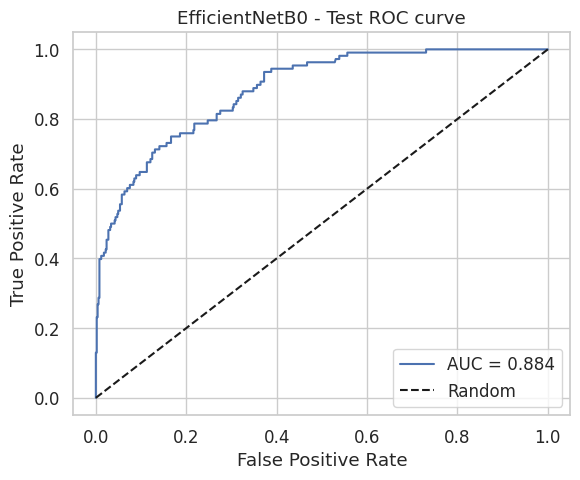


---- Evaluation on ResNet50 - Test ----
Accuracy : 0.8956
Precision: 0.7821
Recall   : 0.5648
F1-score : 0.6559
ROC-AUC  : 0.8996

Classification report:
               precision    recall  f1-score   support

Non_Fractured       0.91      0.97      0.94       505
    Fractured       0.78      0.56      0.66       108

     accuracy                           0.90       613
    macro avg       0.85      0.77      0.80       613
 weighted avg       0.89      0.90      0.89       613

Confusion matrix:
[[488  17]
 [ 47  61]]


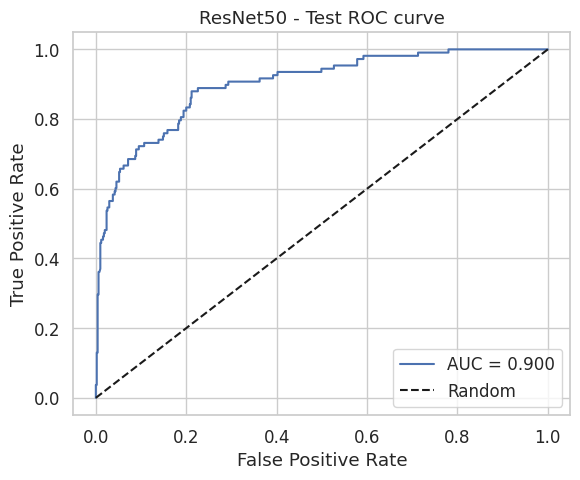


EfficientNetB0 metrics: {'accuracy': 0.8776508972267537, 'precision': 0.7142857142857143, 'recall': 0.5092592592592593, 'f1': 0.5945945945945946, 'roc_auc': 0.8841125779244592}
ResNet50 metrics: {'accuracy': 0.8955954323001631, 'precision': 0.782051282051282, 'recall': 0.5648148148148148, 'f1': 0.6559139784946236, 'roc_auc': 0.8995691235790246}


In [ ]:
eff_metrics = evaluate_model(efficientnet_model, test_loader, "EfficientNetB0 - Test")
plot_roc_binary(efficientnet_model, test_loader,
                "EfficientNetB0 - Test ROC curve")

res_metrics = evaluate_model(resnet_model, test_loader, "ResNet50 - Test")
plot_roc_binary(resnet_model, test_loader,
                "ResNet50 - Test ROC curve")

print("\nEfficientNetB0 metrics:", eff_metrics)
print("ResNet50 metrics:", res_metrics)


In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

model_paths = {
    "EfficientNet-B0": "/kaggle/working/efficientnetb0_fracture_phase2.pt",
    "ResNet50": "/kaggle/working/resnet50_fracture_phase2.pt"
}

for model_name, path in model_paths.items():
    print(f"EVALUATING MODEL: {model_name}\n")
    print(f"\nLoading weights from: {path}")

    try:
        if "EfficientNet" in model_name:
            current_model = build_efficientnet_b0(num_classes=2, freeze=False)
            current_model.load_state_dict(torch.load(path, map_location=device))

        elif "ResNet" in model_name:
            current_model = build_resnet50(num_classes=2, freeze=False)
            current_model.load_state_dict(torch.load(path, map_location=device))

            print("Test-Time Dropout into ResNet for Uncertainty Quantification")
            trained_fc = current_model.fc
            current_model.fc = nn.Sequential(
                nn.Dropout(p=0.2), # 20% dropout
                trained_fc         # trained wts.
            )

        current_model = current_model.to(device)

        # Initialize Uncertainty Quantifier
        uq = UncertaintyQuantifier(current_model, device)
        print(f"Running uncertainty estimation for {model_name}")
        y_probs, y_unc, y_true = uq.predict_with_uncertainty(test_loader, num_samples=20)

        # Generate Clinical Report
        generate_clinical_report(y_true, y_probs, y_unc)

        # Save results
        filename = f"{model_name}_clinical_results.csv"
        pd.DataFrame({
            'y_true': y_true,
            'y_prob': y_probs,
            'uncertainty': y_unc
        }).to_csv(filename, index=False)
        print(f"Saved results to {filename}")

    except Exception as e:
        print(f"FAILED to evaluate {model_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue


EVALUATING MODEL: EfficientNet-B0


Loading weights from: /kaggle/working/efficientnetb0_fracture_phase2.pt
Running uncertainty estimation for EfficientNet-B0
Running Monte Carlo Uncertainty Estimation (20 passes)...

CLINICAL VALIDATION REPORT 
AUROC Score:               0.8831
Sensitivity (Recall):      0.5278
Specificity:               0.9564
PPV (Precision):           0.7215
NPV:                       0.9045
------------------------------------------------------------
OPERATING POINT ANALYSIS (Critical for Radiologists)
Threshold for 95% Sens:    0.0448
Specificity at 95% Sens:   0.5663
------------------------------------------------------------
UNCERTAINTY ANALYSIS (Monte Carlo Dropout)
Mean Uncertainty (Variance): 0.00214
Accuracy on Most Certain 80%: 0.9327 (vs 0.8809 overall)

Saved results to EfficientNet-B0_clinical_results.csv
EVALUATING MODEL: ResNet50


Loading weights from: /kaggle/working/resnet50_fracture_phase2.pt
Test-Time Dropout into ResNet for Uncertainty Quantifi

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


Saved visualization to ResNet50_clinical_visuals.png


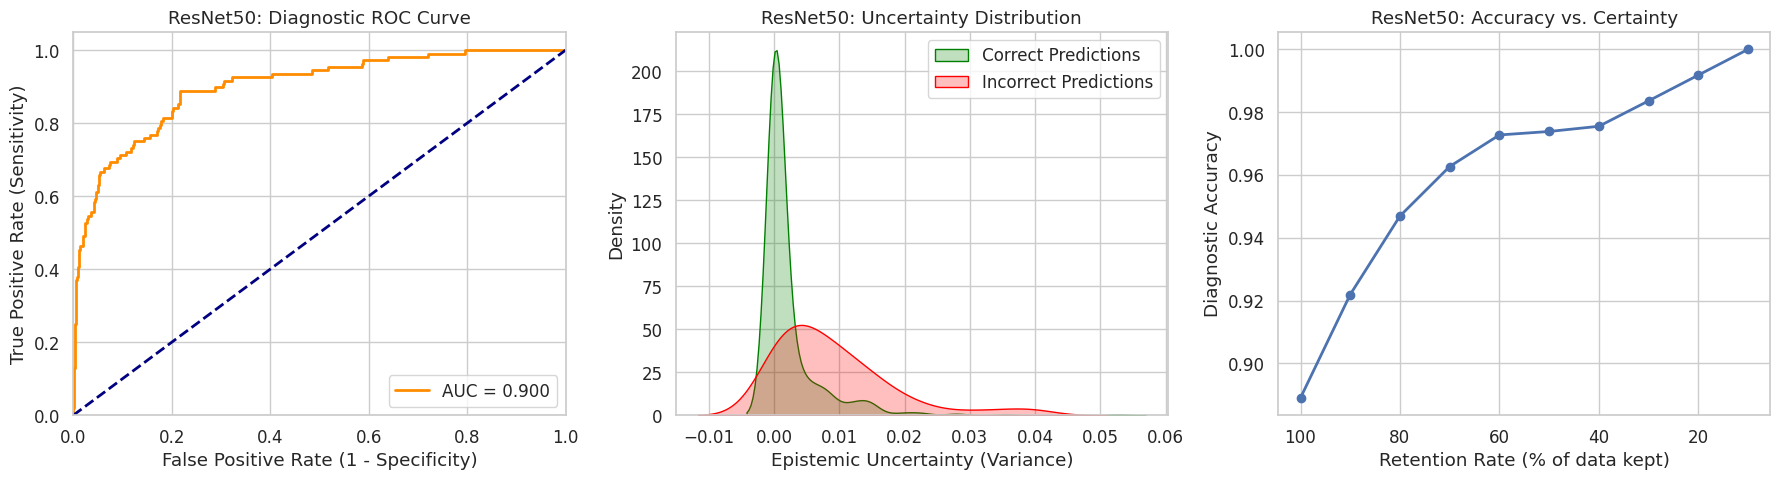

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

def plot_clinical_metrics(model_name="ResNet50"):
    # 1. Load the results you just saved
    try:
        df = pd.read_csv(f"{model_name}_clinical_results.csv")
    except FileNotFoundError:
        print(f"Error: Could not find {model_name}_clinical_results.csv.")
        return

    # Set style
    sns.set_style("whitegrid")
    plt.figure(figsize=(18, 5))

    #  PLOT 1: ROC Curve
    plt.subplot(1, 3, 1)
    fpr, tpr, _ = roc_curve(df['y_true'], df['y_prob'])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title(f'{model_name}: Diagnostic ROC Curve')
    plt.legend(loc="lower right")

    #  PLOT 2: Uncertainty Distribution
    plt.subplot(1, 3, 2)
    df['pred_binary'] = (df['y_prob'] >= 0.5).astype(int)
    correct = df[df['pred_binary'] == df['y_true']]
    incorrect = df[df['pred_binary'] != df['y_true']]

    sns.kdeplot(correct['uncertainty'], fill=True, color='green', label='Correct Predictions')
    sns.kdeplot(incorrect['uncertainty'], fill=True, color='red', label='Incorrect Predictions')
    plt.title(f'{model_name}: Uncertainty Distribution')
    plt.xlabel('Epistemic Uncertainty (Variance)')
    plt.legend()

    #  PLOT 3: Accuracy vs Retention
    plt.subplot(1, 3, 3)

    # Sort by uncertainty (lowest to highest)
    df_sorted = df.sort_values('uncertainty')

    fractions = []
    accuracies = []

    for percent in range(10, 101, 10):
        n = int(len(df) * (percent / 100))
        subset = df_sorted.iloc[:n]
        acc = np.mean(subset['y_true'] == subset['pred_binary'])

        fractions.append(percent)
        accuracies.append(acc)

    plt.plot(fractions, accuracies, marker='o', linewidth=2)
    plt.xlabel('Retention Rate (% of data kept)')
    plt.ylabel('Diagnostic Accuracy')
    plt.title(f'{model_name}: Accuracy vs. Certainty')
    plt.gca().invert_xaxis() # Left = 100% data, Right = 10% best data
    plt.grid(True)

    # Explanation text
    plt.tight_layout()
    plt.savefig(f"{model_name}_clinical_visuals.png", dpi=300)
    print(f"Saved visualization to {model_name}_clinical_visuals.png")
    plt.show()

# Run it for your best model
plot_clinical_metrics("ResNet50")


#Interpretability

In [ ]:
!pip install --no-deps -q grad-cam
!pip install -q --no-deps ttach

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.6 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Grad-Cam

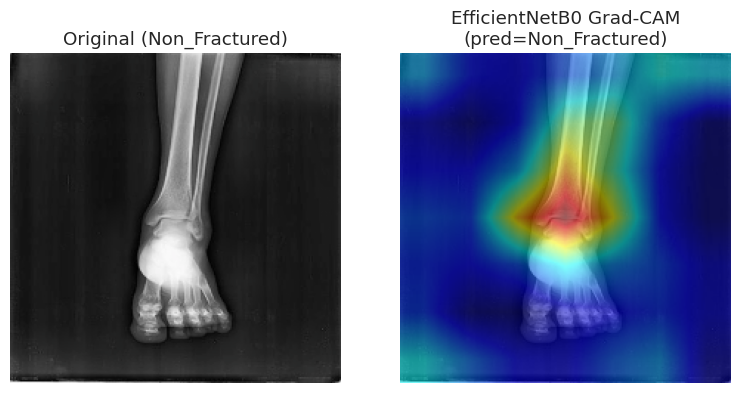

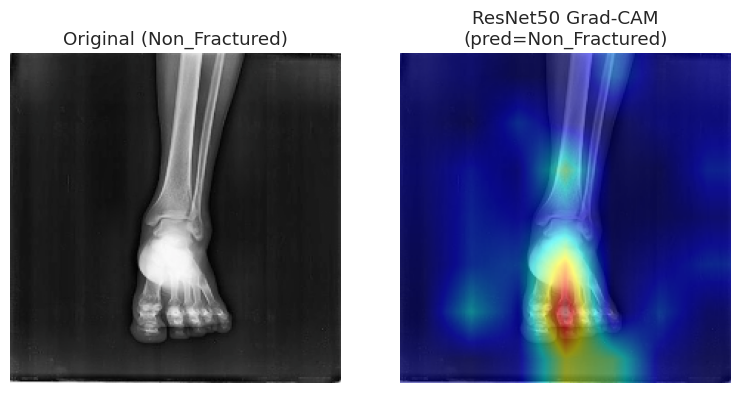

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def tensor_to_numpy_img(tensor):
    img = tensor.numpy().transpose(1, 2, 0)
    img = (img * IMAGENET_STD) + IMAGENET_MEAN
    img = np.clip(img, 0, 1)
    return img

def run_gradcam_for_sample(model, target_layers, loader,
                           sample_index=0, class_idx=None, title="Grad-CAM"):
    model.eval()
    cam = GradCAM(model=model, target_layers=target_layers)

    inputs, labels = next(iter(loader))
    inputs = inputs.to(device)
    labels = labels.to(device)

    idx = min(sample_index, inputs.size(0)-1)
    input_tensor = inputs[idx:idx+1]

    with torch.no_grad():
        outputs = model(input_tensor)
        preds = outputs.argmax(dim=1)
    pred_cls = preds.item()
    if class_idx is None:
        class_idx = pred_cls

    targets = [ClassifierOutputTarget(class_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    img_np = tensor_to_numpy_img(inputs[idx].cpu())
    vis = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title(f"Original ({class_names[labels[idx].item()]})")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(vis)
    plt.title(f"{title}\n(pred={class_names[pred_cls]})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Target layers
eff_target_layers = [efficientnet_model.features[-1]]
res_target_layers = [resnet_model.layer4[-1]]

run_gradcam_for_sample(efficientnet_model, eff_target_layers,
                       test_loader, sample_index=0,
                       title="EfficientNetB0 Grad-CAM")

run_gradcam_for_sample(resnet_model, res_target_layers,
                       test_loader, sample_index=0,
                       title="ResNet50 Grad-CAM")


# SHAP interpretability

  0%|          | 0/1 [00:00<?, ?it/s]

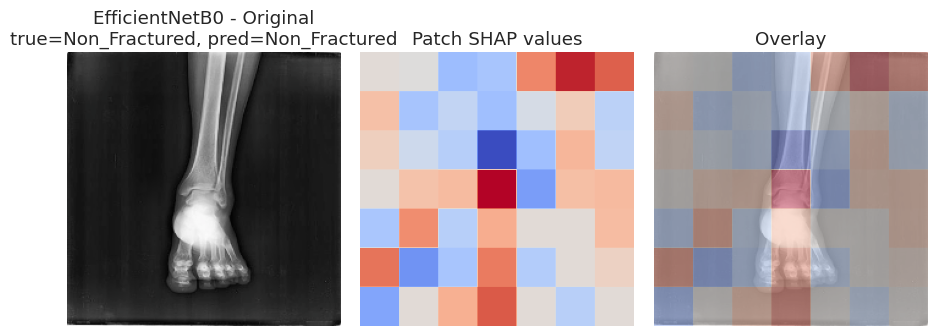

  0%|          | 0/1 [00:00<?, ?it/s]

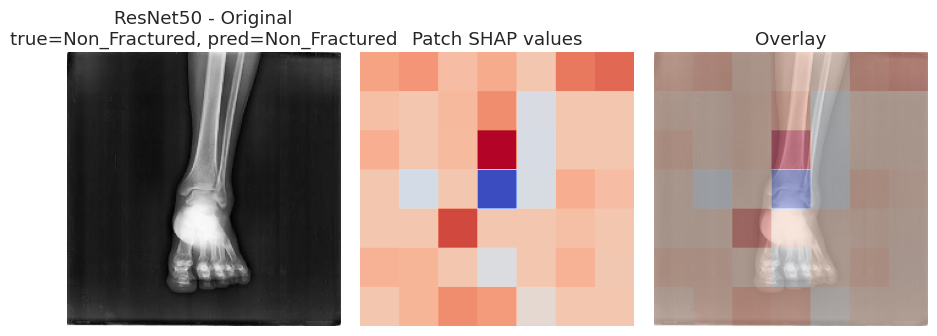

In [ ]:
import shap
shap.initjs()

def get_single_sample(loader, sample_index=0):
    inputs, labels = next(iter(loader))
    idx = min(sample_index, inputs.size(0) - 1)
    return inputs[idx:idx+1].to(device), int(labels[idx].item())

def make_patch_segments(H, W, grid_size=7):
    ys = np.linspace(0, H, grid_size+1, dtype=int)
    xs = np.linspace(0, W, grid_size+1, dtype=int)
    segs = []
    for i in range(grid_size):
        for j in range(grid_size):
            y0, y1 = ys[i], ys[i+1]
            x0, x1 = xs[j], xs[j+1]
            segs.append((y0, y1, x0, x1))
    return segs

def make_shap_model_fn(model, orig_img_np, segments, baseline_value=0.0):
    H, W, _ = orig_img_np.shape
    num_segments = len(segments)

    def f(mask_batch):
        imgs = []
        for mask in mask_batch:
            img = np.full_like(orig_img_np, baseline_value, dtype=np.float32)
            for k, m in enumerate(mask):
                if m == 1:
                    y0,y1,x0,x1 = segments[k]
                    img[y0:y1, x0:x1, :] = orig_img_np[y0:y1, x0:x1, :]
            img_t = torch.from_numpy(img.transpose(2,0,1))
            img_t = (img_t - torch.tensor(IMAGENET_MEAN)[:,None,None]) / torch.tensor(IMAGENET_STD)[:,None,None]
            imgs.append(img_t)

        batch_t = torch.stack(imgs, dim=0).to(device).float()
        with torch.no_grad():
            logits = model(batch_t)
            probs = F.softmax(logits, dim=1)
        return probs.cpu().numpy()

    return f, num_segments

def shap_kernel_heatmap_for_sample(model, loader,
                                   sample_index=0,
                                   grid_size=7,
                                   nsamples=200,
                                   title_prefix="SHAP - "):
    x, y_true = get_single_sample(loader, sample_index)
    x_cpu = x[0].cpu()
    H, W = x_cpu.shape[1], x_cpu.shape[2]

    orig_np = tensor_to_numpy_img(x_cpu)

    segments = make_patch_segments(H, W, grid_size=grid_size)
    f, num_segments = make_shap_model_fn(model, orig_np, segments, baseline_value=orig_np.mean())

    background = np.zeros((1, num_segments), dtype=np.float32)
    sample    = np.ones((1, num_segments), dtype=np.float32)

    explainer = shap.KernelExplainer(f, background)
    shap_values = explainer.shap_values(sample, nsamples=nsamples)

    shap_seg = shap_values[y_true][0]
    heatmap = np.zeros((H, W), dtype=np.float32)
    for val, (y0,y1,x0,x1) in zip(shap_seg, segments):
        heatmap[y0:y1, x0:x1] = val

    h_min, h_max = heatmap.min(), heatmap.max()
    if h_max > h_min:
        heatmap = (heatmap - h_min) / (h_max - h_min + 1e-8)

    with torch.no_grad():
        probs = F.softmax(model(x), dim=1).cpu().numpy()[0]
    pred_cls = int(np.argmax(probs))

    plt.figure(figsize=(9,4))
    plt.subplot(1,3,1)
    plt.imshow(orig_np)
    plt.title(f"{title_prefix}Original\ntrue={class_names[y_true]}, pred={class_names[pred_cls]}")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap="coolwarm")
    plt.title("Patch SHAP values")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(orig_np, alpha=0.6)
    plt.imshow(heatmap, cmap="coolwarm", alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

shap_kernel_heatmap_for_sample(
    model=efficientnet_model,
    loader=test_loader,
    sample_index=0,
    grid_size=7,
    nsamples=200,
    title_prefix="EfficientNetB0 - "
)

shap_kernel_heatmap_for_sample(
    model=resnet_model,
    loader=test_loader,
    sample_index=0,
    grid_size=7,
    nsamples=200,
    title_prefix="ResNet50 - "
)
